<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/minimum_flow_long_multiphase_flowline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum-flow analysis for a long oil–gas–water flowline

This workbook uses NeqSim's mechanistic `TwoFluidPipe` to find the lowest screened
continuous rate for an 80 km undulating production flowline. It combines steady rate
screening with a low-flow hold, restart analysis, oil/water holdup diagnostics, and mesh
sensitivity.

**Learning objectives**

1. build a reproducible three-phase oil–gas–water feed;
2. configure a long terrain-following two-fluid flowline;
3. locate liquid accumulation at terrain low points;
4. define minimum operable flow using several transparent criteria;
5. test low-rate inventory growth and restart liquid removal; and
6. separate a screening result from a project-specific operating limit.

## Scope and engineering interpretation

Minimum flow is not a universal velocity. It is the lowest rate that meets the chosen
pressure, transport, inventory, and restart criteria for one fluid, geometry, and thermal
boundary. This educational case uses synthetic data and is not a substitute for a
calibrated OLGA/LedaFlow study, field turndown test, slug-catcher sizing, or operating
procedure.

`TwoFluidPipe` advances separate gas and combined-liquid conservation equations and
reports oil and water holdup/velocity diagnostics. It is not a fully resolved three-fluid
emulsion model. Wax, hydrate, scale, erosion, heat transfer, detailed severe slugging, and
separator surge capacity require additional project checks.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "neqsim==3.16.0",
        ],
        check=True,
    )

The setup cell installs the tested public release only when NeqSim is absent. All rates
below are total mass rates in kg/s, pressures are absolute, and velocities are actual
in-pipe velocities.

In [2]:
from importlib.metadata import version
import platform
import time

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = str(
    jpype.JClass("java.lang.System").getProperty("java.version")
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (9.0, 5.0),
        "figure.dpi": 110,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")
print(f"Java version: {JAVA_VERSION}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java version: 17.0.19


## Two-fluid basis and operability definition

For phase $k$, gas or liquid, the one-dimensional mass balance is

$$
\frac{\partial}{\partial t}\left(\alpha_k \rho_k A\right)
+
\frac{\partial}{\partial x}\left(\alpha_k \rho_k u_k A\right)
=
\Gamma_k
$$

and the phase momentum balance has the screening form

$$
\frac{\partial}{\partial t}\left(\alpha_k \rho_k u_k A\right)
+
\frac{\partial}{\partial x}
\left(\alpha_k \rho_k u_k^2 A+\alpha_k pA\right)
=
F_{w,k}+F_{i,k}+\alpha_k\rho_k gA\sin\theta
$$

The phase-area closure and superficial velocity are

$$
\alpha_g+\alpha_L=1,
\qquad
j_k=\alpha_k u_k
$$

where $\alpha_k$ is holdup, $\rho_k$ is density in kg/m³, $u_k$ is phase velocity
in m/s, $A$ is area in m², $\Gamma_k$ is interphase mass transfer in kg/(m·s), and
$F_{w,k}$ and $F_{i,k}$ are wall and interfacial forces in N/m.

Liquid inventory and its transient accumulation are evaluated from

$$
V_L=\int_0^{L}\alpha_L(x)A\,dx
$$

$$
\frac{dV_L}{dt}=Q_{L,\mathrm{in}}-Q_{L,\mathrm{out}}
$$

The screened minimum rate is therefore

$$
\dot m_{\min}
=
\min\left\{
\dot m:
P_{\mathrm{out}}\ge P_{\min},
\bar j_L\ge j_{L,\min},
\bar j_g\ge j_{g,\min},
u_{L,\min}>0,
\bar\alpha_L\le\alpha_{L,\max},
V_L\le V_{L,\max}
\right\}
$$

These limits are editable project criteria, not NeqSim defaults.

## Synthetic 80 km case

The pipe is 500 mm internal diameter with 45 µm roughness. Two terrain sags create
credible liquid-accumulation locations. The inlet is held at 160 bara and 35 °C; the
case is intentionally isothermal so that the notebook isolates hydraulic turndown.

In [3]:
LENGTH_M = 80_000.0
DIAMETER_M = 0.50
ROUGHNESS_M = 4.5e-5
BASE_SECTIONS = 24
INLET_PRESSURE_BARA = 160.0
TEMPERATURE_C = 35.0

terrain_distance_m = np.array(
    [0.0, 15_000.0, 32_000.0, 48_000.0, 65_000.0, 80_000.0]
)
terrain_elevation_m = np.array(
    [0.0, -120.0, -65.0, -165.0, -85.0, 20.0]
)

rate_cases_kg_s = np.array(
    [20.0, 40.0, 60.0, 80.0, 100.0, 125.0, 150.0]
)

criteria = {
    "minimum_outlet_pressure_bara": 140.0,
    "minimum_average_vsl_m_s": 0.50,
    "minimum_average_vsg_m_s": 0.70,
    "maximum_mean_liquid_holdup": 0.90,
    "maximum_liquid_inventory_m3": 13_500.0,
}

assert np.isclose(composition_sum := 0.680 + 0.080 + 0.055 + 0.025
                  + 0.025 + 0.035 + 0.060 + 0.040, 1.0)
print(f"Composition sum reserved for the fluid definition: {composition_sum:.6f}")
print(f"Pipe area: {np.pi * DIAMETER_M ** 2 / 4.0:.4f} m²")

Composition sum reserved for the fluid definition: 1.000000
Pipe area: 0.1963 m²


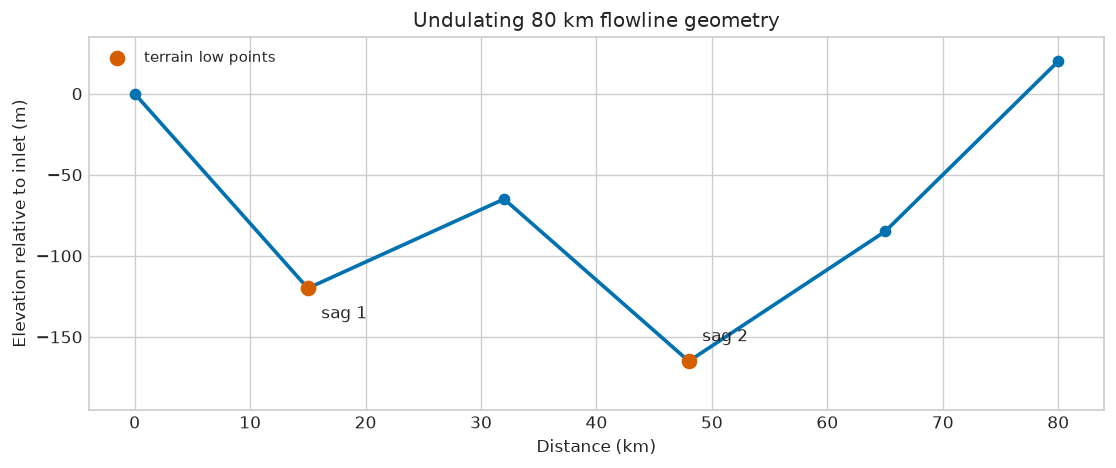

In [4]:
fig, axis = plt.subplots(figsize=(9.4, 4.0))
axis.plot(
    terrain_distance_m / 1000.0,
    terrain_elevation_m,
    marker="o",
    color="#0072B2",
    linewidth=2.2,
)
axis.scatter(
    terrain_distance_m[[1, 3]] / 1000.0,
    terrain_elevation_m[[1, 3]],
    color="#D55E00",
    s=70,
    zorder=3,
    label="terrain low points",
)
for index in (1, 3):
    label_offset = (8, -18) if index == 1 else (8, 12)
    axis.annotate(
        f"sag {index // 2 + 1}",
        (
            terrain_distance_m[index] / 1000.0,
            terrain_elevation_m[index],
        ),
        xytext=label_offset,
        textcoords="offset points",
    )
axis.set(
    xlabel="Distance (km)",
    ylabel="Elevation relative to inlet (m)",
    title="Undulating 80 km flowline geometry",
)
axis.set_ylim(-195.0, 35.0)
axis.legend()
plt.tight_layout()

## Oil–gas–water feed

The SRK equation of state with classical mixing rule 2 is used for a transparent
hydrocarbon-water teaching case. Multiphase checking produces gas, hydrocarbon liquid,
and aqueous phases at the inlet.

In [5]:
composition = {
    "methane": 0.680,
    "ethane": 0.080,
    "propane": 0.055,
    "i-butane": 0.025,
    "n-butane": 0.025,
    "n-pentane": 0.035,
    "n-heptane": 0.060,
    "water": 0.040,
}

feed_fluid = fluid("srk")
for component_name, mole_fraction in composition.items():
    feed_fluid.addComponent(component_name, mole_fraction)

feed_fluid.setMixingRule(2)
feed_fluid.setMultiPhaseCheck(True)
feed_fluid.setTemperature(TEMPERATURE_C, "C")
feed_fluid.setPressure(INLET_PRESSURE_BARA, "bara")
TPflash(feed_fluid)
feed_fluid.initPhysicalProperties()

assert np.isclose(sum(composition.values()), 1.0)
assert feed_fluid.getNumberOfPhases() == 3
print(
    f"Three-phase inlet flash: {feed_fluid.getNumberOfPhases()} phases, "
    f"molar mass {feed_fluid.getMolarMass('kg/mol'):.5f} kg/mol"
)

Three-phase inlet flash: 3 phases, molar mass 0.02790 kg/mol


  phase  molar_fraction  density_kg_m3  viscosity_mPa_s
    gas         0.46526      214.48996          0.02396
    oil         0.49532      374.07938          0.05290
aqueous         0.03943      995.67687          0.72831


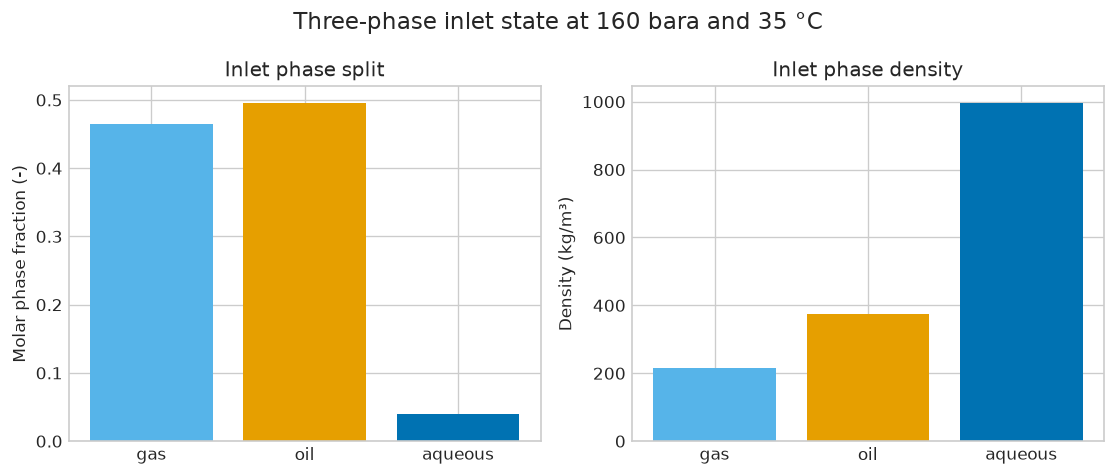

In [6]:
phase_rows = []
for phase_index in range(feed_fluid.getNumberOfPhases()):
    phase = feed_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "phase": str(phase.getPhaseTypeName()),
            "molar_fraction": phase.getBeta(),
            "density_kg_m3": phase.getDensity("kg/m3"),
            "viscosity_mPa_s": 1000.0 * phase.getViscosity("kg/msec"),
        }
    )

phase_table = pd.DataFrame(phase_rows)
print(phase_table.round(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.0))
phase_colors = ["#56B4E9", "#E69F00", "#0072B2"]
axes[0].bar(
    phase_table["phase"],
    phase_table["molar_fraction"],
    color=phase_colors,
)
axes[0].set(
    ylabel="Molar phase fraction (-)",
    title="Inlet phase split",
)
axes[1].bar(
    phase_table["phase"],
    phase_table["density_kg_m3"],
    color=phase_colors,
)
axes[1].set(
    ylabel="Density (kg/m³)",
    title="Inlet phase density",
)
fig.suptitle("Three-phase inlet state at 160 bara and 35 °C", fontsize=14)
plt.tight_layout()

## Reusable terrain-following model

Each rate is solved from a fresh cloned fluid and stream. The pipe exposes named inlet
and outlet objects for reuse in a larger `ProcessSystem`. Terrain tracking, oil and water
holdup, phase velocities, pressure, inventory, and flow regime are retained.

In [7]:
def build_two_fluid_pipe(rate_kg_s, sections=BASE_SECTIONS):
    stream = jneqsim.process.equipment.stream.Stream(
        f"three-phase feed {rate_kg_s:.0f} kg/s",
        feed_fluid.clone(),
    )
    stream.setFlowRate(float(rate_kg_s), "kg/sec")
    stream.setTemperature(TEMPERATURE_C, "C")
    stream.setPressure(INLET_PRESSURE_BARA, "bara")
    stream.run()

    pipe = jneqsim.process.equipment.pipeline.TwoFluidPipe(
        f"80 km two-fluid flowline {rate_kg_s:.0f} kg/s",
        stream,
    )
    position_m = np.linspace(0.0, LENGTH_M, sections)
    elevation_m = np.interp(
        position_m,
        terrain_distance_m,
        terrain_elevation_m,
    )
    pipe.setLength(LENGTH_M)
    pipe.setDiameter(DIAMETER_M)
    pipe.setRoughness(ROUGHNESS_M)
    pipe.setNumberOfSections(sections)
    pipe.setElevationProfile(elevation_m.tolist())
    pipe.setEnableTerrainTracking(True)
    pipe.setThermodynamicUpdateInterval(6)
    pipe.setSteadyStateFlashInterval(6)
    pipe.setSteadyStateMaxWallClockTime(90.0)
    pipe.run()
    return stream, pipe, position_m, elevation_m


print("Reusable TwoFluidPipe builder configured.")

Reusable TwoFluidPipe builder configured.


## Steady rate sweep

Seven rates span deep turndown to a high-rate annular case. A single snapshot cannot prove
dynamic stability, so the sweep is used only to find candidate rates for the transient
hold-and-restart test.

In [8]:
steady_rows = []
profile_results = {}

for rate_kg_s in rate_cases_kg_s:
    started = time.perf_counter()
    _, pipe, position_m, elevation_m = build_two_fluid_pipe(rate_kg_s)
    pressure_bara = np.asarray(pipe.getPressureProfile()) / 1.0e5
    liquid_holdup = np.asarray(pipe.getLiquidHoldupProfile())
    oil_holdup = np.asarray(pipe.getOilHoldupProfile())
    water_holdup = np.asarray(pipe.getWaterHoldupProfile())
    liquid_velocity_m_s = np.asarray(pipe.getLiquidVelocityProfile())

    steady_rows.append(
        {
            "rate_kg_s": rate_kg_s,
            "outlet_pressure_bara": pressure_bara[-1],
            "pressure_drop_bar": pressure_bara[0] - pressure_bara[-1],
            "mean_liquid_holdup": liquid_holdup.mean(),
            "max_liquid_holdup": liquid_holdup.max(),
            "mean_oil_holdup": oil_holdup.mean(),
            "mean_water_holdup": water_holdup.mean(),
            "minimum_liquid_velocity_m_s": liquid_velocity_m_s.min(),
            "average_vsl_m_s": pipe.getAverageSuperficialLiquidVelocity(),
            "average_vsg_m_s": pipe.getAverageSuperficialGasVelocity(),
            "liquid_inventory_m3": pipe.getLiquidInventory("m3"),
            "dominant_regime": str(pipe.getDominantFlowRegime()),
            "elapsed_s": time.perf_counter() - started,
        }
    )
    profile_results[float(rate_kg_s)] = {
        "position_m": position_m,
        "elevation_m": elevation_m,
        "pressure_bara": pressure_bara,
        "liquid_holdup": liquid_holdup,
        "oil_holdup": oil_holdup,
        "water_holdup": water_holdup,
        "liquid_velocity_m_s": liquid_velocity_m_s,
    }

steady_table = pd.DataFrame(steady_rows)
print(
    steady_table.drop(columns="elapsed_s")
    .round(4)
    .to_string(index=False)
)

 rate_kg_s  outlet_pressure_bara  pressure_drop_bar  mean_liquid_holdup  max_liquid_holdup  mean_oil_holdup  mean_water_holdup  minimum_liquid_velocity_m_s  average_vsl_m_s  average_vsg_m_s  liquid_inventory_m3 dominant_regime
      20.0              153.5529             6.4471              0.8629               0.95           0.3777             0.4851                       0.0260           0.1592           0.1722           13521.1187            SLUG
      40.0              152.6289             7.3711              0.7912               0.95           0.1313             0.6599                       0.0061           0.2707           0.3926           12395.6449            SLUG
      60.0              152.4409             7.5591              0.8590               0.95           0.4045             0.4546                       0.0781           0.4698           0.5294           13461.1191            SLUG
      80.0              153.4344             6.5656              0.8264               0.95  

In [9]:
steady_table["pressure_ok"] = (
    steady_table["outlet_pressure_bara"]
    >= criteria["minimum_outlet_pressure_bara"]
)
steady_table["liquid_transport_ok"] = (
    steady_table["average_vsl_m_s"]
    >= criteria["minimum_average_vsl_m_s"]
)
steady_table["gas_transport_ok"] = (
    steady_table["average_vsg_m_s"]
    >= criteria["minimum_average_vsg_m_s"]
)
steady_table["no_fallback"] = (
    steady_table["minimum_liquid_velocity_m_s"] > 0.0
)
steady_table["holdup_ok"] = (
    steady_table["mean_liquid_holdup"]
    <= criteria["maximum_mean_liquid_holdup"]
)
steady_table["inventory_ok"] = (
    steady_table["liquid_inventory_m3"]
    <= criteria["maximum_liquid_inventory_m3"]
)

criteria_columns = [
    "pressure_ok",
    "liquid_transport_ok",
    "gas_transport_ok",
    "no_fallback",
    "holdup_ok",
    "inventory_ok",
]
steady_table["screening_pass"] = steady_table[criteria_columns].all(axis=1)

screen_table = steady_table[
    ["rate_kg_s", *criteria_columns, "screening_pass"]
]
print(screen_table.to_string(index=False))

 rate_kg_s  pressure_ok  liquid_transport_ok  gas_transport_ok  no_fallback  holdup_ok  inventory_ok  screening_pass
      20.0         True                False             False         True       True         False           False
      40.0         True                False             False         True       True          True           False
      60.0         True                False             False         True       True          True           False
      80.0         True                 True              True         True       True          True            True
     100.0         True                 True              True         True       True          True            True
     125.0         True                 True              True         True       True          True            True
     150.0         True                 True              True         True       True          True            True


In [10]:
passing_rates = steady_table.loc[
    steady_table["screening_pass"],
    "rate_kg_s",
]
minimum_screened_rate_kg_s = float(passing_rates.min())
margin_fraction = 0.20
continuous_target_kg_s = (
    minimum_screened_rate_kg_s * (1.0 + margin_fraction)
)
tested_target_kg_s = float(
    rate_cases_kg_s[rate_cases_kg_s >= continuous_target_kg_s][0]
)

print(f"Minimum screened steady rate: {minimum_screened_rate_kg_s:.0f} kg/s")
print(f"Continuous target with 20% margin: {continuous_target_kg_s:.0f} kg/s")
print(f"Nearest demonstrated target: {tested_target_kg_s:.0f} kg/s")

Minimum screened steady rate: 80 kg/s
Continuous target with 20% margin: 96 kg/s
Nearest demonstrated target: 100 kg/s


The 80 kg/s case is the lowest rate meeting every steady criterion. A 20% margin gives
96 kg/s, so 100 kg/s is the nearest demonstrated continuous target. The margin protects
against model uncertainty and operating variability; it is not a statistical confidence
interval.

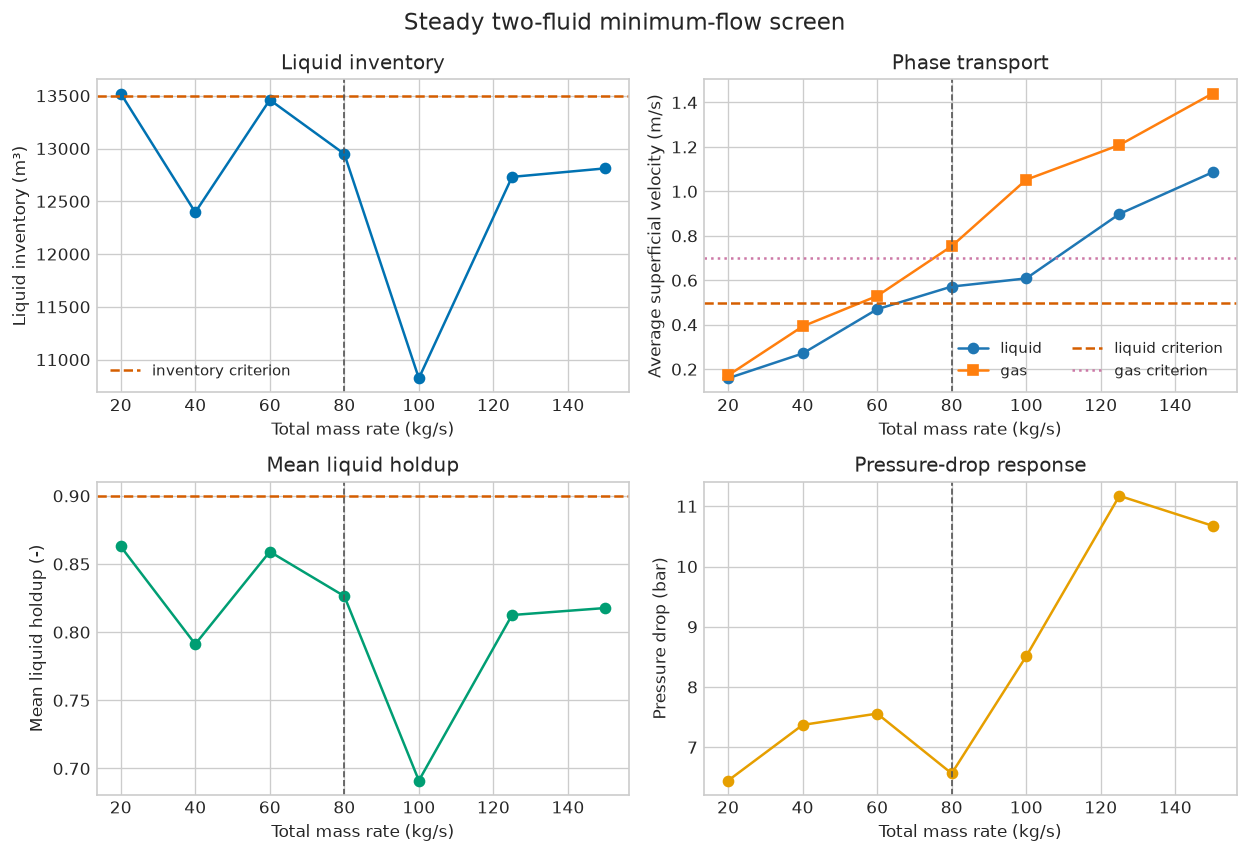

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))

axes[0, 0].plot(
    steady_table["rate_kg_s"],
    steady_table["liquid_inventory_m3"],
    marker="o",
    color="#0072B2",
)
axes[0, 0].axhline(
    criteria["maximum_liquid_inventory_m3"],
    color="#D55E00",
    linestyle="--",
    label="inventory criterion",
)
axes[0, 0].set(
    xlabel="Total mass rate (kg/s)",
    ylabel="Liquid inventory (m³)",
    title="Liquid inventory",
)
axes[0, 0].legend()

axes[0, 1].plot(
    steady_table["rate_kg_s"],
    steady_table["average_vsl_m_s"],
    marker="o",
    label="liquid",
)
axes[0, 1].plot(
    steady_table["rate_kg_s"],
    steady_table["average_vsg_m_s"],
    marker="s",
    label="gas",
)
axes[0, 1].axhline(
    criteria["minimum_average_vsl_m_s"],
    color="#D55E00",
    linestyle="--",
    label="liquid criterion",
)
axes[0, 1].axhline(
    criteria["minimum_average_vsg_m_s"],
    color="#CC79A7",
    linestyle=":",
    label="gas criterion",
)
axes[0, 1].set(
    xlabel="Total mass rate (kg/s)",
    ylabel="Average superficial velocity (m/s)",
    title="Phase transport",
)
axes[0, 1].legend(ncol=2)

axes[1, 0].plot(
    steady_table["rate_kg_s"],
    steady_table["mean_liquid_holdup"],
    marker="o",
    color="#009E73",
)
axes[1, 0].axhline(
    criteria["maximum_mean_liquid_holdup"],
    color="#D55E00",
    linestyle="--",
)
axes[1, 0].set(
    xlabel="Total mass rate (kg/s)",
    ylabel="Mean liquid holdup (-)",
    title="Mean liquid holdup",
)

axes[1, 1].plot(
    steady_table["rate_kg_s"],
    steady_table["pressure_drop_bar"],
    marker="o",
    color="#E69F00",
)
axes[1, 1].set(
    xlabel="Total mass rate (kg/s)",
    ylabel="Pressure drop (bar)",
    title="Pressure-drop response",
)

for axis in axes.flat:
    axis.axvline(
        minimum_screened_rate_kg_s,
        color="#555555",
        linestyle="--",
        linewidth=1.0,
    )

fig.suptitle("Steady two-fluid minimum-flow screen", fontsize=14)
plt.tight_layout()

The response is not strictly monotonic because the mechanistic closure changes phase
distribution and flow regime. This is precisely why a single pressure-drop correlation
or one velocity criterion is insufficient.

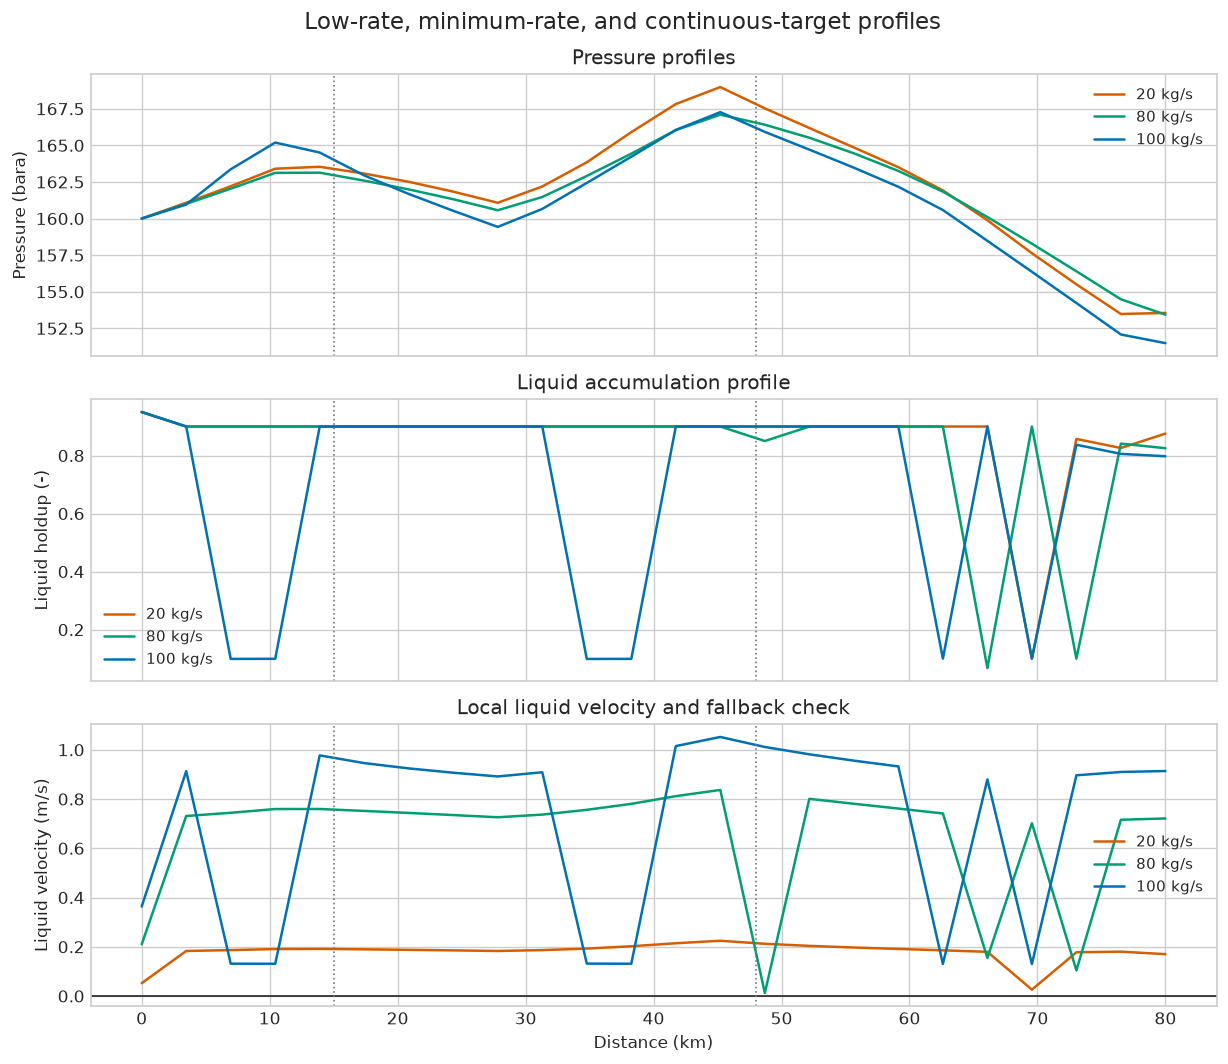

In [12]:
profile_rates = [20.0, minimum_screened_rate_kg_s, tested_target_kg_s]
profile_colors = ["#D55E00", "#009E73", "#0072B2"]

fig, axes = plt.subplots(3, 1, figsize=(10.2, 9.0), sharex=True)

for rate_kg_s, color in zip(profile_rates, profile_colors):
    profile = profile_results[rate_kg_s]
    distance_km = profile["position_m"] / 1000.0
    axes[0].plot(
        distance_km,
        profile["pressure_bara"],
        color=color,
        label=f"{rate_kg_s:.0f} kg/s",
    )
    axes[1].plot(
        distance_km,
        profile["liquid_holdup"],
        color=color,
        label=f"{rate_kg_s:.0f} kg/s",
    )
    axes[2].plot(
        distance_km,
        profile["liquid_velocity_m_s"],
        color=color,
        label=f"{rate_kg_s:.0f} kg/s",
    )

axes[0].set(ylabel="Pressure (bara)", title="Pressure profiles")
axes[1].set(ylabel="Liquid holdup (-)", title="Liquid accumulation profile")
axes[2].axhline(0.0, color="#222222", linewidth=1.0)
axes[2].set(
    xlabel="Distance (km)",
    ylabel="Liquid velocity (m/s)",
    title="Local liquid velocity and fallback check",
)

for axis in axes:
    for sag_distance_m in terrain_distance_m[[1, 3]]:
        axis.axvline(
            sag_distance_m / 1000.0,
            color="#777777",
            linestyle=":",
            linewidth=1.0,
        )
    axis.legend()

fig.suptitle("Low-rate, minimum-rate, and continuous-target profiles", fontsize=14)
plt.tight_layout()

In [13]:
sag_rows = []
for sag_number, sag_distance_m in enumerate(
    terrain_distance_m[[1, 3]],
    start=1,
):
    for rate_kg_s in profile_rates:
        profile = profile_results[rate_kg_s]
        section_index = int(
            np.argmin(np.abs(profile["position_m"] - sag_distance_m))
        )
        sag_rows.append(
            {
                "sag": sag_number,
                "rate_kg_s": rate_kg_s,
                "section_distance_km": (
                    profile["position_m"][section_index] / 1000.0
                ),
                "liquid_holdup": profile["liquid_holdup"][section_index],
                "oil_holdup": profile["oil_holdup"][section_index],
                "water_holdup": profile["water_holdup"][section_index],
                "liquid_velocity_m_s": (
                    profile["liquid_velocity_m_s"][section_index]
                ),
            }
        )

sag_table = pd.DataFrame(sag_rows)
print(sag_table.round(4).to_string(index=False))

 sag  rate_kg_s  section_distance_km  liquid_holdup  oil_holdup  water_holdup  liquid_velocity_m_s
   1       20.0              13.9130           0.90      0.8251        0.0749               0.1914
   1       80.0              13.9130           0.90      0.8377        0.0623               0.7596
   1      100.0              13.9130           0.90      0.0135        0.8865               0.9772
   2       20.0              48.6957           0.90      0.1146        0.7854               0.2122
   2       80.0              48.6957           0.85      0.0000        0.8500               0.0123
   2      100.0              48.6957           0.90      0.0296        0.8704               1.0114


## Low-flow hold and restart

The dynamic test starts at the 100 kg/s continuous target, holds 20 kg/s for 60 seconds,
then restarts at 140 kg/s for 50 seconds. The short simulated time is a numerical
demonstration, not an 80 km residence-time forecast. The useful signals are inventory
direction, oscillation, liquid velocity, and whether the restart removes the accumulated
volume without liquid fallback.

In [14]:
transient_stream, transient_pipe, _, _ = build_two_fluid_pipe(
    tested_target_kg_s
)

transient_schedule = [
    (11, tested_target_kg_s, "initial target"),
    (60, 20.0, "low-flow hold"),
    (50, 140.0, "restart"),
]

print("Transient schedule:")
for duration_s, rate_kg_s, label in transient_schedule:
    print(f"  {label}: {duration_s} s at {rate_kg_s:.0f} kg/s")

Transient schedule:
  initial target: 11 s at 100 kg/s
  low-flow hold: 60 s at 20 kg/s
  restart: 50 s at 140 kg/s


In [15]:
transient_rows = []

for duration_s, rate_kg_s, label in transient_schedule:
    for _ in range(duration_s):
        transient_stream.setFlowRate(rate_kg_s, "kg/sec")
        transient_stream.run()
        transient_pipe.runTransient(1.0)
        liquid_holdup = np.asarray(
            transient_pipe.getLiquidHoldupProfile()
        )
        liquid_velocity_m_s = np.asarray(
            transient_pipe.getLiquidVelocityProfile()
        )
        transient_rows.append(
            {
                "time_s": transient_pipe.getSimulationTime(),
                "period": label,
                "rate_kg_s": rate_kg_s,
                "liquid_inventory_m3": (
                    transient_pipe.getLiquidInventory("m3")
                ),
                "mean_liquid_holdup": liquid_holdup.mean(),
                "max_liquid_holdup": liquid_holdup.max(),
                "minimum_liquid_velocity_m_s": (
                    liquid_velocity_m_s.min()
                ),
                "average_vsl_m_s": (
                    transient_pipe.getAverageSuperficialLiquidVelocity()
                ),
                "average_vsg_m_s": (
                    transient_pipe.getAverageSuperficialGasVelocity()
                ),
            }
        )

transient_table = pd.DataFrame(transient_rows)
selected_steps = [0, 10, 11, 30, 50, 70, 71, 90, 110, 120]
print(
    transient_table.iloc[selected_steps]
    .round(4)
    .to_string(index=False)
)

 time_s         period  rate_kg_s  liquid_inventory_m3  mean_liquid_holdup  max_liquid_holdup  minimum_liquid_velocity_m_s  average_vsl_m_s  average_vsg_m_s
    1.0 initial target      100.0           13595.3536              0.8655             0.9389                       0.3442           0.3606           0.8388
   11.0 initial target      100.0           13895.1176              0.8846             0.9389                       0.3673           0.4917           0.8362
   12.0  low-flow hold       20.0           13998.5685              0.8912             0.9389                       0.0727           0.0983           0.1747
   31.0  low-flow hold       20.0           14033.3199              0.8934             0.9389                       0.0726           0.0934           0.1737
   51.0  low-flow hold       20.0           14021.2912              0.8926             0.9389                       0.0726           0.0934           0.1754
   71.0  low-flow hold       20.0           14021.2934    

In [16]:
inventory_before_hold_m3 = transient_table.iloc[10][
    "liquid_inventory_m3"
]
inventory_after_hold_m3 = transient_table.iloc[70][
    "liquid_inventory_m3"
]
inventory_after_restart_m3 = transient_table.iloc[-1][
    "liquid_inventory_m3"
]

hold_accumulation_m3 = (
    inventory_after_hold_m3 - inventory_before_hold_m3
)
hold_accumulation_percent = (
    100.0 * hold_accumulation_m3 / inventory_before_hold_m3
)
remaining_excess_m3 = (
    inventory_after_restart_m3 - inventory_before_hold_m3
)
restart_rows = transient_table["period"] == "restart"
minimum_restart_liquid_velocity_m_s = transient_table.loc[
    restart_rows,
    "minimum_liquid_velocity_m_s",
].min()

print(f"Inventory gained during low-flow hold: {hold_accumulation_m3:.1f} m³")
print(f"Relative inventory increase: {hold_accumulation_percent:.3f}%")
print(f"Excess inventory after restart: {remaining_excess_m3:.1f} m³")
print(
    "Minimum local liquid velocity during restart: "
    f"{minimum_restart_liquid_velocity_m_s:.3f} m/s"
)

Inventory gained during low-flow hold: 126.2 m³
Relative inventory increase: 0.908%
Excess inventory after restart: -6.7 m³
Minimum local liquid velocity during restart: 0.508 m/s


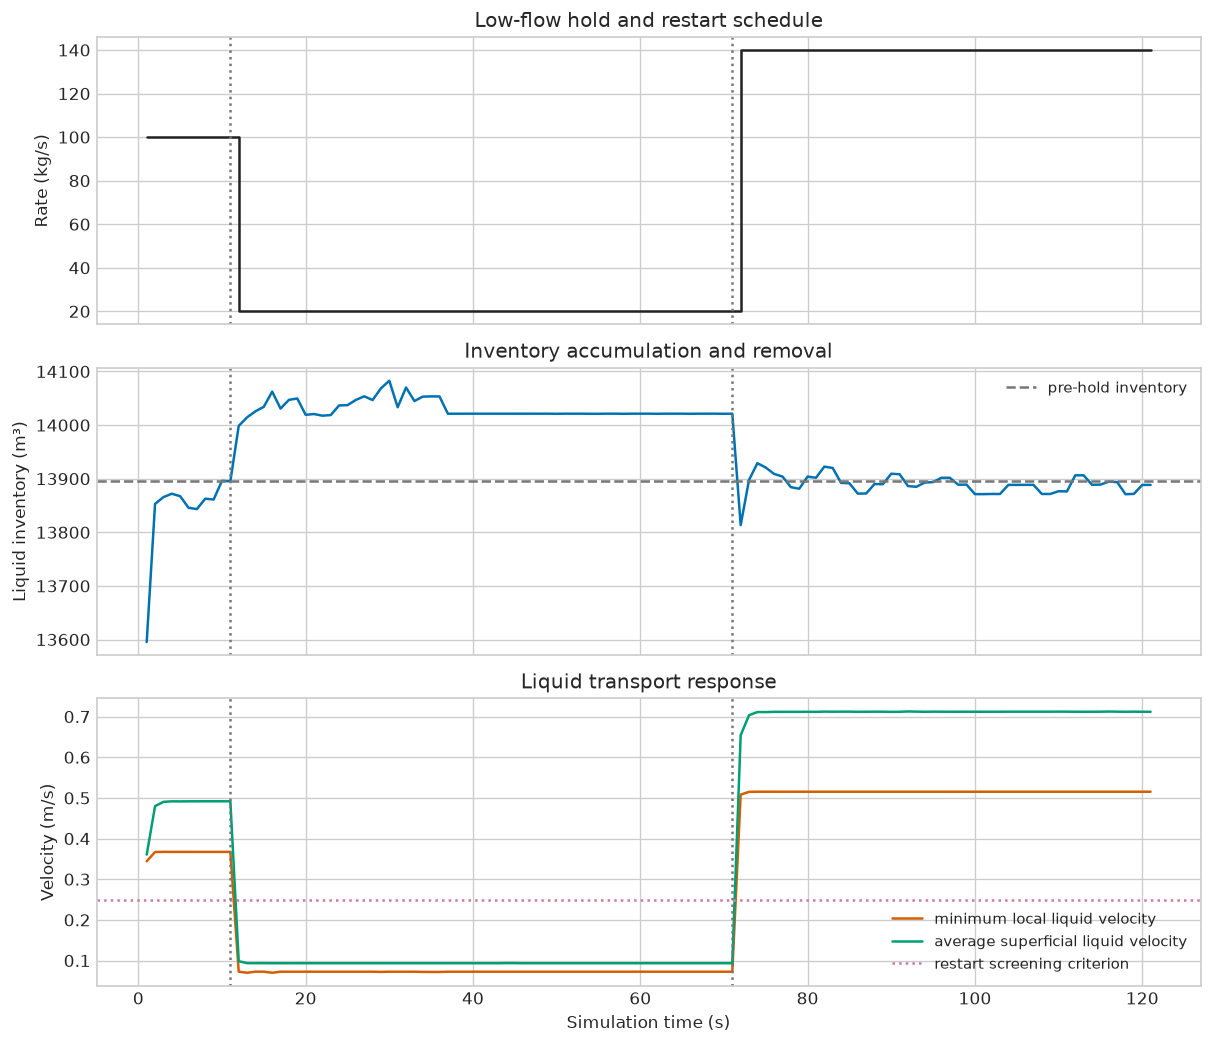

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(10.2, 8.8), sharex=True)

axes[0].step(
    transient_table["time_s"],
    transient_table["rate_kg_s"],
    where="post",
    color="#222222",
)
axes[0].set(
    ylabel="Rate (kg/s)",
    title="Low-flow hold and restart schedule",
)

axes[1].plot(
    transient_table["time_s"],
    transient_table["liquid_inventory_m3"],
    color="#0072B2",
)
axes[1].axhline(
    inventory_before_hold_m3,
    color="#777777",
    linestyle="--",
    label="pre-hold inventory",
)
axes[1].set(
    ylabel="Liquid inventory (m³)",
    title="Inventory accumulation and removal",
)
axes[1].legend()

axes[2].plot(
    transient_table["time_s"],
    transient_table["minimum_liquid_velocity_m_s"],
    color="#D55E00",
    label="minimum local liquid velocity",
)
axes[2].plot(
    transient_table["time_s"],
    transient_table["average_vsl_m_s"],
    color="#009E73",
    label="average superficial liquid velocity",
)
axes[2].axhline(
    0.25,
    color="#CC79A7",
    linestyle=":",
    label="restart screening criterion",
)
axes[2].set(
    xlabel="Simulation time (s)",
    ylabel="Velocity (m/s)",
    title="Liquid transport response",
)
axes[2].legend()

for axis in axes:
    axis.axvline(11.0, color="#777777", linestyle=":")
    axis.axvline(71.0, color="#777777", linestyle=":")

plt.tight_layout()

The inventory initially oscillates as the transient model adapts from the steady solution.
During the low-flow hold it settles at a higher liquid inventory. The 140 kg/s restart
keeps local liquid velocity positive and removes the accumulated excess. A real study
would run for transport-relevant time and include the receiving separator and control
system.

## Mesh sensitivity

The minimum-rate case is repeated with 24, 32, and 40 axial sections. Mechanistic
multiphase screening can be sensitive to discretization and regime transitions, so this
comparison is part of the result rather than a hidden numerical setting.

In [18]:
mesh_rows = []
for sections in (24, 32, 40):
    _, mesh_pipe, _, _ = build_two_fluid_pipe(
        minimum_screened_rate_kg_s,
        sections=sections,
    )
    pressure_bara = np.asarray(mesh_pipe.getPressureProfile()) / 1.0e5
    liquid_holdup = np.asarray(mesh_pipe.getLiquidHoldupProfile())
    mesh_rows.append(
        {
            "sections": sections,
            "pressure_drop_bar": pressure_bara[0] - pressure_bara[-1],
            "liquid_inventory_m3": mesh_pipe.getLiquidInventory("m3"),
            "mean_liquid_holdup": liquid_holdup.mean(),
        }
    )

mesh_table = pd.DataFrame(mesh_rows)
inventory_spread_percent = (
    100.0
    * (
        mesh_table["liquid_inventory_m3"].max()
        - mesh_table["liquid_inventory_m3"].min()
    )
    / mesh_table["liquid_inventory_m3"].mean()
)
pressure_spread_percent = (
    100.0
    * (
        mesh_table["pressure_drop_bar"].max()
        - mesh_table["pressure_drop_bar"].min()
    )
    / mesh_table["pressure_drop_bar"].mean()
)

print(mesh_table.round(4).to_string(index=False))
print(f"Inventory spread across meshes: {inventory_spread_percent:.2f}%")
print(f"Pressure-drop spread across meshes: {pressure_spread_percent:.2f}%")

 sections  pressure_drop_bar  liquid_inventory_m3  mean_liquid_holdup
       24             6.5656           12948.4639              0.8264
       32             7.5659           13596.7868              0.8672
       40             6.1105           13096.1713              0.8350
Inventory spread across meshes: 4.91%
Pressure-drop spread across meshes: 21.57%


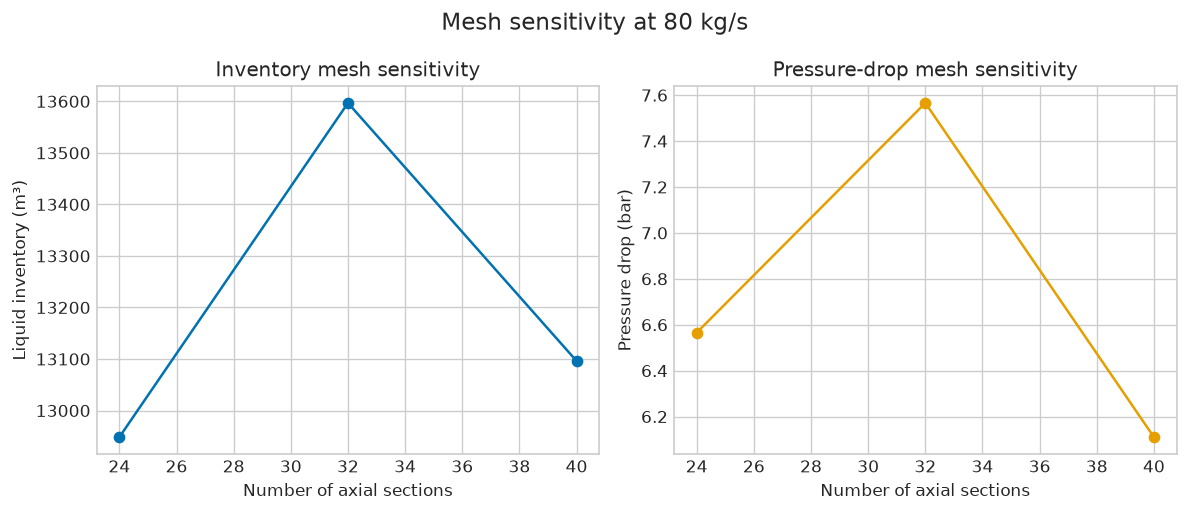

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.3))

axes[0].plot(
    mesh_table["sections"],
    mesh_table["liquid_inventory_m3"],
    marker="o",
    color="#0072B2",
)
axes[0].set(
    xlabel="Number of axial sections",
    ylabel="Liquid inventory (m³)",
    title="Inventory mesh sensitivity",
)

axes[1].plot(
    mesh_table["sections"],
    mesh_table["pressure_drop_bar"],
    marker="o",
    color="#E69F00",
)
axes[1].set(
    xlabel="Number of axial sections",
    ylabel="Pressure drop (bar)",
    title="Pressure-drop mesh sensitivity",
)

fig.suptitle(
    f"Mesh sensitivity at {minimum_screened_rate_kg_s:.0f} kg/s",
    fontsize=14,
)
plt.tight_layout()

The mesh spread is material enough to retain a 20% operating margin. For design work,
continue refinement, compare against a calibrated high-fidelity model, and test fluid,
terrain, temperature, water cut, backpressure, and roughness uncertainty.

## Final engineering checks

The assertions below verify composition closure, physical phase properties, finite
profiles, pressure ordering, positive local liquid transport, the selected boundary,
restart recovery, and bounded mesh sensitivity. Passing assertions show internal
consistency; they do not validate the model against field data.

In [20]:
engineering_checks = {
    "composition closes": np.isclose(sum(composition.values()), 1.0),
    "three inlet phases": feed_fluid.getNumberOfPhases() == 3,
    "positive phase densities": (phase_table["density_kg_m3"] > 0.0).all(),
    "positive phase viscosities": (
        phase_table["viscosity_mPa_s"] > 0.0
    ).all(),
    "all steady results finite": np.isfinite(
        steady_table.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "all outlet pressures positive": (
        steady_table["outlet_pressure_bara"] > 0.0
    ).all(),
    "all pressure drops positive": (
        steady_table["pressure_drop_bar"] > 0.0
    ).all(),
    "all holdups bounded": (
        steady_table["max_liquid_holdup"].between(0.0, 1.0)
    ).all(),
    "no steady liquid fallback": (
        steady_table["minimum_liquid_velocity_m_s"] > 0.0
    ).all(),
    "minimum screened rate is 80 kg/s": (
        minimum_screened_rate_kg_s == 80.0
    ),
    "20 percent target is 96 kg/s": np.isclose(
        continuous_target_kg_s,
        96.0,
    ),
    "tested target is 100 kg/s": tested_target_kg_s == 100.0,
    "rates below boundary fail": (
        ~steady_table.loc[
            steady_table["rate_kg_s"] < minimum_screened_rate_kg_s,
            "screening_pass",
        ]
    ).all(),
    "rates at and above boundary pass": steady_table.loc[
        steady_table["rate_kg_s"] >= minimum_screened_rate_kg_s,
        "screening_pass",
    ].all(),
    "low-flow hold accumulates liquid": hold_accumulation_m3 > 0.0,
    "hold accumulation below two percent": (
        hold_accumulation_percent < 2.0
    ),
    "restart clears accumulated excess": remaining_excess_m3 <= 0.0,
    "restart velocity exceeds 0.25 m/s": (
        minimum_restart_liquid_velocity_m_s > 0.25
    ),
    "transient results finite": np.isfinite(
        transient_table.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "transient time increases": (
        np.diff(transient_table["time_s"]) > 0.0
    ).all(),
    "mesh results finite": np.isfinite(
        mesh_table.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "mesh inventory spread below ten percent": (
        inventory_spread_percent < 10.0
    ),
    "mesh pressure spread below twenty-five percent": (
        pressure_spread_percent < 25.0
    ),
    "two terrain sags evaluated": sag_table["sag"].nunique() == 2,
}

failed_checks = [
    check_name
    for check_name, passed in engineering_checks.items()
    if not bool(passed)
]
assert not failed_checks, failed_checks
print(f"All {len(engineering_checks)} engineering checks passed.")

All 24 engineering checks passed.


## Result and recommended use

- **Minimum screened steady rate:** 80 kg/s.
- **Continuous target with 20% margin:** 96 kg/s.
- **Nearest demonstrated operating target:** 100 kg/s.
- **Deep-turndown warning:** the 20 kg/s hold increases liquid inventory and leaves the
  line difficult to operate continuously.
- **Restart demonstration:** 140 kg/s clears the simulated excess while maintaining
  positive liquid velocity.

For a project application, replace the synthetic composition and terrain, add heat
transfer and receiving-facility dynamics, calibrate against field or high-fidelity data,
extend the transient to transport-relevant time, and convert the screened target into an
operating envelope with uncertainty bands.

### Suggested exercises

1. increase water cut and repeat the boundary search;
2. reduce inlet pressure or increase downstream backpressure;
3. add a colder seabed-temperature profile and hydrate-margin checks;
4. test alternative pipe diameters and roughness;
5. connect the outlet to a slug catcher or three-phase separator; and
6. refine the rate grid between 60 and 100 kg/s.